# Import Liberaies

In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
import ast
%matplotlib inline

# Read Data

In [85]:
charging=pd.read_csv("data/charging_sessions.csv")
charging.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil..."
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil..."


# Data processing

## parse the userInputs columncolumn

In [86]:
charging_copy=charging.copy()

In [87]:
# Define a function to parse the userInputs column.
def parse_user_inputs(user_inputs):
    if pd.isna(user_inputs) or user_inputs == '':
        return {}
    try:
        # Convert a string to a dictionary.
        parsed_data = ast.literal_eval(user_inputs)
        if isinstance(parsed_data, list):
            parsed_data = parsed_data[0]
        return parsed_data
    except (ValueError, SyntaxError):
        return {}

In [88]:
userInputs_df = charging_copy['userInputs'].apply(parse_user_inputs).apply(pd.Series)
userInputs_df

,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,250.0,25.00,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT",194.0
1,280.0,70.00,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT",4275.0
2,400.0,8.00,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT",344.0
3,400.0,8.00,20.0,65.0,"Thu, 02 Jan 2020 14:00:03 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT",1117.0
4,400.0,16.00,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT",334.0
...,...,...,...,...,...,...,...,...
66445,240.0,31.20,130.0,355.0,"Wed, 31 Jul 2019 18:08:23 GMT",True,"Thu, 01 Aug 2019 00:03:04 GMT",393.0
66446,333.0,6.66,20.0,455.0,"Wed, 31 Jul 2019 18:41:02 GMT",True,"Thu, 01 Aug 2019 02:15:41 GMT",220.0
66447,333.0,19.98,60.0,184.0,"Wed, 31 Jul 2019 19:04:57 GMT",True,"Wed, 31 Jul 2019 22:08:40 GMT",1974.0
66448,275.0,22.00,80.0,60.0,"Wed, 31 Jul 2019 19:20:10 GMT",True,"Wed, 31 Jul 2019 20:19:47 GMT",942.0


In [89]:
charging.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


In [90]:
userInputs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   WhPerMile           49187 non-null  float64
 1   kWhRequested        49187 non-null  float64
 2   milesRequested      49187 non-null  float64
 3   minutesAvailable    49187 non-null  float64
 4   modifiedAt          49187 non-null  object 
 5   paymentRequired     49187 non-null  object 
 6   requestedDeparture  49187 non-null  object 
 7   userID              49187 non-null  float64
dtypes: float64(5), object(3)
memory usage: 4.1+ MB


In [91]:
userInputs_df['modifiedAt']=pd.to_datetime(userInputs_df['modifiedAt'])
userInputs_df['requestedDeparture']=pd.to_datetime(userInputs_df['requestedDeparture'])

In [92]:
userInputs_df.head()

,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,250.0,25.0,100.0,463.0,2020-01-02 13:09:39,True,2020-01-02 20:51:54,194.0
1,280.0,70.0,250.0,595.0,2020-01-02 13:37:11,True,2020-01-02 23:31:50,4275.0
2,400.0,8.0,20.0,60.0,2020-01-02 13:57:17,True,2020-01-02 14:56:35,344.0
3,400.0,8.0,20.0,65.0,2020-01-02 14:00:03,True,2020-01-02 15:04:58,1117.0
4,400.0,16.0,40.0,504.0,2020-01-02 14:00:13,True,2020-01-02 22:24:01,334.0


In [93]:
charging_copy = pd.concat([charging_copy.drop(columns=['userInputs','userID']), userInputs_df], axis=1)

In [94]:
charging_copy.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,250.0,25.0,100.0,463.0,2020-01-02 13:09:39,True,2020-01-02 20:51:54,194.0
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,280.0,70.0,250.0,595.0,2020-01-02 13:37:11,True,2020-01-02 23:31:50,4275.0
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,400.0,8.0,20.0,60.0,2020-01-02 13:57:17,True,2020-01-02 14:56:35,344.0
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,400.0,8.0,20.0,65.0,2020-01-02 14:00:03,True,2020-01-02 15:04:58,1117.0
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,400.0,16.0,40.0,504.0,2020-01-02 14:00:13,True,2020-01-02 22:24:01,334.0


## Missing values

### Mssing values in userInputs

In [95]:
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1,keys=['missing_number','missing_percent'])
    total_missing_number=missing_number.sum()
    total_missing_percent=missing_percent.sum()
    total_row=pd.DataFrame([[total_missing_number,total_missing_percent]],
                           columns=['missing_number','missing_percent'],
                           index=['total'])
    missing_values=pd.concat([missing_values,total_row])
    return missing_values
# Define a function to show the number and percentage of missing values for each column, as well as the total number of missing values in the entire dataset.

In [96]:
missing(charging_copy)

,missing_number,missing_percent
userID,17263,0.259789
requestedDeparture,17263,0.259789
paymentRequired,17263,0.259789
modifiedAt,17263,0.259789
minutesAvailable,17263,0.259789
milesRequested,17263,0.259789
kWhRequested,17263,0.259789
WhPerMile,17263,0.259789
doneChargingTime,4088,0.061520
timezone,0,0.000000


In [97]:
charging_copy['WhPerMile']=charging_copy['WhPerMile'].fillna(value='unknown')
charging_copy['kWhRequested']=charging_copy['kWhRequested'].fillna(value='unknown')
charging_copy['milesRequested']=charging_copy['milesRequested'].fillna(value='unknown')
charging_copy['minutesAvailable']=charging_copy['minutesAvailable'].fillna(value='unknown')
charging_copy['modifiedAt']=charging_copy['modifiedAt'].fillna(value='unknown')
charging_copy['paymentRequired']=charging_copy['paymentRequired'].fillna(value='unknown')
charging_copy['requestedDeparture']=charging_copy['requestedDeparture'].fillna(value='unknown')
charging_copy['userID']=charging_copy['userID'].fillna(value='unknown')


In [98]:
missing(charging_copy)

,missing_number,missing_percent
doneChargingTime,4088,0.06152
Unnamed: 0,0,0.00000
timezone,0,0.00000
requestedDeparture,0,0.00000
paymentRequired,0,0.00000
modifiedAt,0,0.00000
minutesAvailable,0,0.00000
milesRequested,0,0.00000
kWhRequested,0,0.00000
WhPerMile,0,0.00000


### Missing values in doneChargingTime

####  fill the doneChargingTime column with the values from the requestedDeparture column.

In [99]:
charging_copy['doneChargingTime']=pd.to_datetime(charging_copy['doneChargingTime'])
charging_copy['connectionTime']=pd.to_datetime(charging_copy['connectionTime'])
charging_copy['disconnectTime']=pd.to_datetime(charging_copy['disconnectTime'])

In [100]:
charging_copy['timezone'].unique()

array(['America/Los_Angeles'], dtype=object)

In [101]:
##Since the dataset only contains one timezone, we can remove the timezone information from the datetime values.
charging_copy['connectionTime'] = pd.to_datetime(charging_copy['connectionTime']).dt.tz_localize(None)
charging_copy['disconnectTime'] = pd.to_datetime(charging_copy['disconnectTime']).dt.tz_localize(None)
charging_copy['doneChargingTime']=pd.to_datetime(charging_copy['doneChargingTime']).dt.tz_localize(None)


In [102]:
charging_copy['doneChargingTime'] = charging_copy.apply(lambda row: row['requestedDeparture'] if pd.isna(row['doneChargingTime']) and row['requestedDeparture'] != 'unknown' else row['doneChargingTime'],axis=1)


In [103]:
missing(charging_copy)

,missing_number,missing_percent
doneChargingTime,909,0.013679
Unnamed: 0,0,0.000000
timezone,0,0.000000
requestedDeparture,0,0.000000
paymentRequired,0,0.000000
modifiedAt,0,0.000000
minutesAvailable,0,0.000000
milesRequested,0,0.000000
kWhRequested,0,0.000000
WhPerMile,0,0.000000


In [104]:
### 

In [105]:
charging_copy['Connection_Time'] = charging_copy['disconnectTime'] - charging_copy['connectionTime']
charging_copy['Charging_Time']=charging_copy['doneChargingTime']-charging_copy['connectionTime']
charging_copy['Idle_Time']=charging_copy['Connection_Time']-charging_copy['Charging_Time']

In [106]:
charging_copy['Connection_Time'] = charging_copy['Connection_Time'].dt.total_seconds() / 60
charging_copy['Charging_Time'] = charging_copy['Charging_Time'].dt.total_seconds() / 60
charging_copy['Idle_Time'] = charging_copy['Idle_Time'].dt.total_seconds() / 60

##### Analyse Charging Time

In [107]:
print(charging_copy[charging_copy['Charging_Time'] < 0])
# There are 27 rows where doneChargingTime is earlier than connectionTime.

       Unnamed: 0                        id      connectionTime  \
22219        2040  5c942ca4f9af8b06b04b3bb4 2019-03-05 19:13:55   
22253        2074  5c957e1cf9af8b42f440af03 2019-03-06 20:26:30   
23562        3383  5cca3a22f9af8b49aaa4cba0 2019-04-15 20:24:13   
23586        3407  5ccb8ba6f9af8b4d9721df00 2019-04-16 16:11:08   
27689        7510  5d856f1ff9af8b0c7bdf245c 2019-09-04 16:35:04   
27740        7561  5d86c0a5f9af8b1022a81870 2019-09-05 18:44:57   
29295        9116  5dcdffbdf9af8b220a19be8b 2019-10-29 17:22:32   
31285         492  5bc91740f9af8b0dc677b860 2018-05-04 19:08:37   
31287         494  5bc91740f9af8b0dc677b862 2018-05-04 19:23:52   
31403         610  5bc917d0f9af8b0dc677b8d6 2018-05-07 20:47:51   
35840        5047  5bc92c03f9af8b0dc677ca2b 2018-07-19 15:57:19   
38884        8091  5bc937f6f9af8b0dc677d60f 2018-08-29 05:25:08   
39875        9082  5bc93c1cf9af8b0dc677d9ee 2018-09-11 15:15:01   
41263       10470  5bc94185f9af8b0dc677df5a 2018-09-27 22:58:4

In [108]:
# According to business logic, doneChargingTime cannot be earlier than connectionTime. Therefore, we delete 27 rows where doneChargingTime is earlier than connectionTime.
charging_copy = charging_copy.drop(charging_copy[charging_copy['Charging_Time'] < 0].index)

In [112]:
print(charging_copy[charging_copy['Idle_Time'] < 0])
# There are 6631 rows where disconnectTime is earlier than doneChargingTime.

       Unnamed: 0                        id      connectionTime  \
12             12  5e23b149f9af8b5fe4b973db 2020-01-02 15:04:38   
20             20  5e23b149f9af8b5fe4b973e3 2020-01-02 15:28:47   
25             25  5e23b149f9af8b5fe4b973e8 2020-01-02 15:42:05   
26             26  5e23b149f9af8b5fe4b973e9 2020-01-02 15:57:24   
33             33  5e23b149f9af8b5fe4b973f0 2020-01-02 16:34:35   
...           ...                       ...                 ...   
66432       10070  5d574ad2f9af8b4c10c03645 2019-07-31 14:36:02   
66439       10077  5d574ad2f9af8b4c10c0364c 2019-07-31 14:45:02   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   
66447       10085  5d574ad2f9af8b4c10c03654 2019-07-31 19:04:40   

           disconnectTime    doneChargingTime  kWhDelivered  \
12    2020-01-02 22:08:39 2020-01-02 22:09:36        25.567   
20    2020-01-02 19:01:54 2020-01-02 19:02:51         7.417   
25    

In [113]:
 A=charging_copy['connectionTime'] > charging_copy['disconnectTime']
A.sum()

In [115]:
A.sum()

0

In [117]:
 B=charging_copy['connectionTime'] > charging_copy['doneChargingTime']
B.sum()

0

In [119]:
C=charging_copy['doneChargingTime'] > charging_copy['disconnectTime']
C.sum()

6631

In [121]:
charging_copy.loc[C, 'doneChargingTime'] = pd.NaT

#####  fill the doneChargingTime column

In [124]:
missing(charging_copy)


,missing_number,missing_percent
doneChargingTime,7540,0.113515
Idle_Time,909,0.013685
Charging_Time,909,0.013685
kWhRequested,0,0.000000
Connection_Time,0,0.000000
userID,0,0.000000
requestedDeparture,0,0.000000
paymentRequired,0,0.000000
modifiedAt,0,0.000000
minutesAvailable,0,0.000000


In [126]:
charging_time_median = charging_copy['Charging_Time'].median()
charging_copy['Charging_Time'] = charging_copy['Charging_Time'].fillna(value=charging_time_median)
charging_copy['doneChargingTime'] = charging_copy['doneChargingTime'].fillna(value=charging_copy['connectionTime'] + pd.to_timedelta(charging_copy['Charging_Time'], unit='m'))

In [127]:
missing(charging_copy)


,missing_number,missing_percent
Idle_Time,909,0.013685
id,0,0.000000
Charging_Time,0,0.000000
Connection_Time,0,0.000000
userID,0,0.000000
requestedDeparture,0,0.000000
paymentRequired,0,0.000000
modifiedAt,0,0.000000
minutesAvailable,0,0.000000
milesRequested,0,0.000000


In [128]:
C=charging_copy['doneChargingTime'] > charging_copy['disconnectTime']
C.sum()

6868

In [131]:
charging_copy.loc[C, 'doneChargingTime'] = pd.NaT

In [132]:
charging_copy['doneChargingTime'] = charging_copy['doneChargingTime'].fillna(charging_copy['disconnectTime'])

In [134]:
C=charging_copy['doneChargingTime'] > charging_copy['disconnectTime']
C.sum()

0

In [135]:
missing(charging_copy)

,missing_number,missing_percent
Idle_Time,909,0.013685
id,0,0.000000
Charging_Time,0,0.000000
Connection_Time,0,0.000000
userID,0,0.000000
requestedDeparture,0,0.000000
paymentRequired,0,0.000000
modifiedAt,0,0.000000
minutesAvailable,0,0.000000
milesRequested,0,0.000000


In [136]:
charging_copy = charging_copy.drop(columns=['Idle_Time','Charging_Time','Connection_Time'])

## Finding outliers

In [147]:
charging_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66423 entries, 0 to 66449
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Unnamed: 0          66423 non-null  int64         
 1   id                  66423 non-null  object        
 2   connectionTime      66423 non-null  datetime64[ns]
 3   disconnectTime      66423 non-null  datetime64[ns]
 4   doneChargingTime    66423 non-null  datetime64[ns]
 5   kWhDelivered        66423 non-null  float64       
 6   sessionID           66423 non-null  object        
 7   siteID              66423 non-null  int64         
 8   spaceID             66423 non-null  object        
 9   stationID           66423 non-null  object        
 10  timezone            66423 non-null  object        
 11  WhPerMile           66423 non-null  object        
 12  kWhRequested        66423 non-null  object        
 13  milesRequested      66423 non-null  object        


In [138]:
def plot_outliers(column):
    charging_copy[column].plot(kind='box', vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(f"{column}")
    plt.show()
    Q1 = charging_copy[column].quantile(0.25)
    Q3 = charging_copy[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = charging_copy[(charging_copy[column] < lower_bound)|(charging_copy[column] > upper_bound)]
    print(outliers)

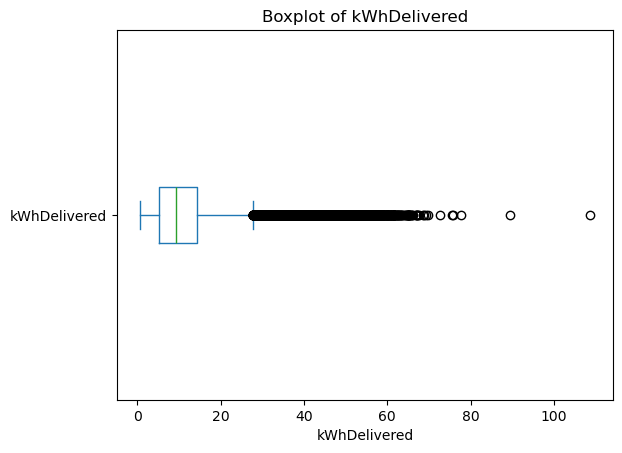

       Unnamed: 0                        id      connectionTime  \
1               1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
6               6  5e23b149f9af8b5fe4b973d5 2020-01-02 14:09:14   
7               7  5e23b149f9af8b5fe4b973d6 2020-01-02 14:17:32   
13             13  5e23b149f9af8b5fe4b973dc 2020-01-02 15:15:27   
21             21  5e23b149f9af8b5fe4b973e4 2020-01-02 15:30:19   
...           ...                       ...                 ...   
66425       10063  5d574ad2f9af8b4c10c0363e 2019-07-31 14:10:15   
66428       10066  5d574ad2f9af8b4c10c03641 2019-07-31 14:30:47   
66433       10071  5d574ad2f9af8b4c10c03646 2019-07-31 14:38:24   
66440       10078  5d574ad2f9af8b4c10c0364d 2019-07-31 14:45:29   
66445       10083  5d574ad2f9af8b4c10c03652 2019-07-31 18:08:04   

           disconnectTime    doneChargingTime  kWhDelivered  \
1     2020-01-02 22:38:21 2020-01-02 20:18:05        33.097   
6     2020-01-03 01:57:58 2020-01-03 00:59:21        43.477   
7     

In [141]:
plot_outliers('kWhDelivered')

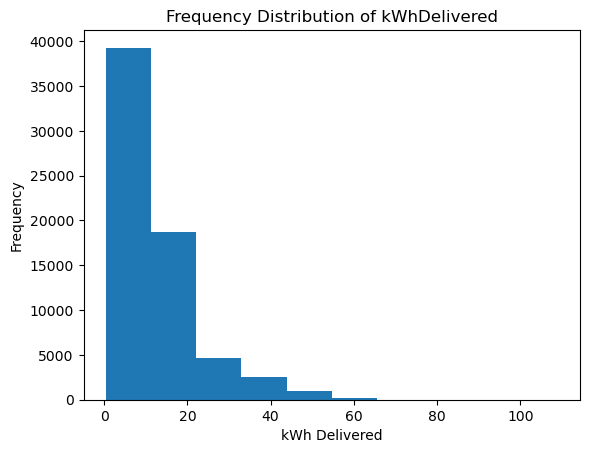

In [143]:
plt.hist(charging_copy['kWhDelivered'])
plt.title('Frequency Distribution of kWhDelivered')
plt.xlabel('kWh Delivered')
plt.ylabel('Frequency')
plt.show()

## Delete unnecessary columns

In [151]:
charging_df = charging_copy.drop(columns=['Unnamed: 0'])

In [152]:
charging_copy.to_csv('processed_data_charging.csv', index=False)